# Práctica de Redes Neuronales - Notebook 1

## Bootcamp Python - PY4
## Módulo 3: Deep Learning y NLP

En este notebook vamos a dar nuestros primeros pasos construyendo redes neuronales.

El objetivo de hoy es entender
**qué es lo que realmente pasa por dentro** cuando una red hace una predicción,
antes de empezar a usar la API ("Application Programming Interface") de Keras (o otra libreria) de forma automática.

Vamos a trabajar con un problema real: predecir la fuga de clientes (**Customer
Churn**) de una empresa de telecomunicaciones.

### Lo que vamos a hacer en este notebook:

1. Cargar y explorar el dataset de Churn.
2. Preparar los datos para que una red neuronal los pueda usar (limpieza,
   encoding, scaling).
3. Entender "por debajo del capó" qué hace una neurona y qué hace una capa,
   simulándolo nosotros mismos con numpy, sin usar Keras todavía.
4. Construir nuestro primer modelo real con Keras: el **Modelo A - El
   Minimalista** (una sola capa oculta pequeña).
5. Evaluar el modelo mirando sus curvas de loss y accuracy.

En el próximo notebook vamos a comparar este Modelo A contra el Modelo B (El
Profundo) y el Modelo C (El Optimizado).


## 0. Preparando el entorno

Antes de empezar, importamos las librerías que vamos a necesitar durante todo
el notebook:

- `pandas` y `numpy` para manejar los datos.
- `matplotlib` para graficar.
- `scikit-learn` para el split de train/test y el scaling.
- `tensorflow` / `keras` para construir la red neuronal más adelante.

Si en algún momento borras el código de una celda para practicar, siempre vas
a poder volver a esta lista para saber qué importar.


In [ ]:
# Importamos las librerias para manejo de datos
import pandas as pd
import numpy as np

# Importamos matplotlib para graficar
import matplotlib.pyplot as plt

# Importamos herramientas de preprocesamiento de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Importamos tensorflow y keras para construir la red neuronal
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Fijamos una semilla para que los resultados sean reproducibles
np.random.seed(42)
tf.random.set_seed(42)


## 1. Cargando el dataset de Customer Churn

Vamos a usar el dataset **Telco Customer Churn**, publicado por IBM. Contiene
información de clientes de una empresa de telecomunicaciones: datos
demográficos, servicios contratados, forma de pago, y si el cliente terminó
cancelando su servicio (`Churn`).

Este es el mismo tipo de problema de negocio que vimos en la clase teórica:
clasificar si un cliente se va a ir o no, usando varias variables de
comportamiento.

Vamos a cargar el archivo CSV directamente desde una URL, y hacer una primera
inspección con `head()`, `shape` e `info()`.


In [ ]:
# URL del dataset de Telco Customer Churn
url = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Datasets/Telco-Customer-Churn.csv"

# Cargamos el dataset en un DataFrame de pandas
df = pd.read_csv(url)

# Revisamos las primeras filas
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Revisamos el tamano del dataset (filas, columnas)
print("Dimensiones del dataset:", df.shape)
print()

# Revisamos el tipo de dato de cada columna y si hay valores nulos evidentes
df.info()


Dimensiones del dataset: (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paper

## Diccionario de datos: Telco Customer Churn

| Columna | Descripción |
|---|---|
| `customerID` | Identificador único de cada cliente. No aporta información predictiva. |
| `gender` | Género del cliente (`Male` / `Female`). |
| `SeniorCitizen` | Indica si el cliente es adulto mayor (1 = sí, 0 = no). |
| `Partner` | Indica si el cliente tiene pareja (`Yes` / `No`). |
| `Dependents` | Indica si el cliente tiene personas a cargo (`Yes` / `No`). |
| `tenure` | Cantidad de meses que el cliente lleva contratado el servicio. |
| `PhoneService` | Indica si el cliente tiene servicio telefónico (`Yes` / `No`). |
| `MultipleLines` | Indica si el cliente tiene múltiples líneas telefónicas (`Yes` / `No` / `No phone service`). |
| `InternetService` | Tipo de servicio de internet contratado (`DSL` / `Fiber optic` / `No`). |
| `OnlineSecurity` | Indica si el cliente tiene seguridad online contratada (`Yes` / `No` / `No internet service`). |
| `OnlineBackup` | Indica si el cliente tiene backup online contratado (`Yes` / `No` / `No internet service`). |
| `DeviceProtection` | Indica si el cliente tiene protección de dispositivo contratada (`Yes` / `No` / `No internet service`). |
| `TechSupport` | Indica si el cliente tiene soporte técnico contratado (`Yes` / `No` / `No internet service`). |
| `StreamingTV` | Indica si el cliente tiene servicio de streaming de TV (`Yes` / `No` / `No internet service`). |
| `StreamingMovies` | Indica si el cliente tiene servicio de streaming de películas (`Yes` / `No` / `No internet service`). |
| `Contract` | Tipo de contrato (`Month-to-month` / `One year` / `Two year`). |
| `PaperlessBilling` | Indica si el cliente tiene facturación sin papel (`Yes` / `No`). |
| `PaymentMethod` | Método de pago (`Electronic check` / `Mailed check` / `Bank transfer (automatic)` / `Credit card (automatic)`). |
| `MonthlyCharges` | Monto que el cliente paga mensualmente (numérico). |
| `TotalCharges` | Monto total facturado al cliente durante todo el tiempo de contrato (numérico). Tiene algunos valores vacíos que se corrigen en el preprocesamiento. |
| `Churn` | **Variable objetivo**: indica si el cliente canceló el servicio (`Yes` / `No`). |

### Explorando la variable objetivo (target)

Nuestra variable a predecir es `Churn` (Yes / No). Antes de construir cualquier
modelo, siempre es buena práctica revisar cómo está distribuida esta variable:
si está muy desbalanceada (por ejemplo 90 por ciento No y 10 por ciento Yes),
eso afecta cómo debemos interpretar el accuracy más adelante.


Churn
No     5174
Yes    1869
Name: count, dtype: int64


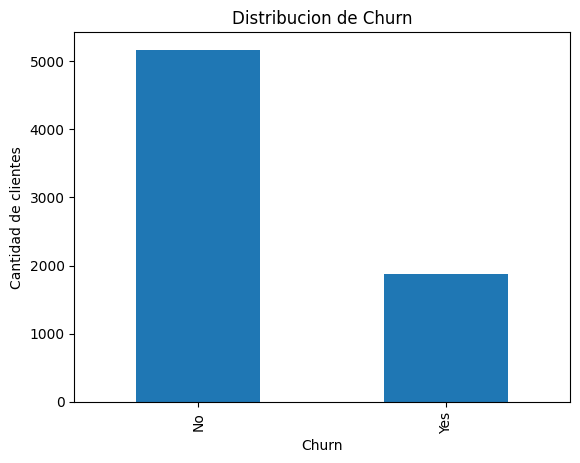

In [ ]:
# Contamos cuantos clientes se fueron (Yes) y cuantos se quedaron (No)
print(df["Churn"].value_counts())

# Graficamos la distribucion de la variable objetivo
df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribucion de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()


### ¿Cómo se define el Churn en este dataset?

La columna `Churn` indica si el cliente **canceló el servicio durante el último mes**.

En este dataset no se sabe exactemente qué se considera "irse": puede incluir tanto una cancelación voluntaria (el cliente llama y da de baja el servicio) como una baja involuntaria (por ejemplo, corte por falta de pago).


## 2. Preprocesamiento de datos

Uno de los **errores más comunes** al entrenar
redes neuronales es no preparar bien los datos. Vamos a hacer los siguientes
pasos, en orden:

1. **Eliminar `customerID`**: es un identificador único, no aporta información
   para predecir el churn.
2. **Corregir `TotalCharges`**: esta columna debería ser numérica, pero tiene
   algunos valores vacíos (espacios en blanco) que hacen que pandas la lea como
   texto. Vamos a convertirla a número y resolver esos valores faltantes.
3. **Codificar la variable objetivo**: convertir `Churn` de Yes/No a 1/0.
4. **Codificar las variables categóricas** (`gender`, `Contract`,
   `PaymentMethod`, etc.) usando `pd.get_dummies`, porque una red neuronal solo
   entiende números.

Este paso de encoding es clave: una red neuronal no puede recibir texto como
input, solo números.


In [ ]:
# Hacemos una copia del dataset original para no modificarlo directamente
data = df.copy()

# Eliminamos la columna customerID, no aporta valor predictivo
data = data.drop(columns=["customerID"])

# La columna TotalCharges tiene espacios en blanco en vez de numeros
# Los convertimos a NaN y luego a tipo numerico
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Revisamos cuantos valores faltantes quedaron
print("Valores faltantes en TotalCharges:", data["TotalCharges"].isna().sum())

# Como son muy pocos casos, simplemente eliminamos esas filas
data = data.dropna(subset=["TotalCharges"])

print("Dimensiones despues de limpiar:", data.shape)


Valores faltantes en TotalCharges: 11
Dimensiones despues de limpiar: (7032, 20)


In [ ]:
# Convertimos la variable objetivo Churn de Yes/No a 1/0
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

# Separamos las variables predictoras (X) de la variable objetivo (y)
X = data.drop(columns=["Churn"])
y = data["Churn"]

# Codificamos las variables categoricas con one-hot encoding
X = pd.get_dummies(X, drop_first=True)

print("Cantidad de features despues del encoding:", X.shape[1])
X.head()


Cantidad de features despues del encoding: 30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


### Train / test split y scaling

Ahora dividimos los datos en un conjunto de entrenamiento y uno de prueba, y
aplicamos **scaling** (estandarización) a las variables numéricas.

Este paso es fundamental: las redes neuronales son sensibles a la escala de
los datos. Si una variable va de 0 a 1 y otra de 0 a 10000, la red va a tener
mucha más dificultad para aprender. Por eso usamos `StandardScaler`, que deja
cada variable con media 0 y desviación estándar 1.

Importante: el scaler se ajusta (`fit`) solamente con los datos de
entrenamiento, y luego se aplica (`transform`) tanto a train como a test. Así
evitamos que información del conjunto de test se filtre al entrenamiento.


In [ ]:
# Dividimos en conjunto de entrenamiento (80%) y de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamano de X_train:", X_train.shape)
print("Tamano de X_test:", X_test.shape)


Tamano de X_train: (5625, 30)
Tamano de X_test: (1407, 30)


In [ ]:
# Creamos el scaler y lo ajustamos SOLO con los datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos la misma transformacion al conjunto de test
X_test_scaled = scaler.transform(X_test)

# Guardamos la cantidad de features, la vamos a necesitar para definir la red
n_features = X_train_scaled.shape[1]
print("Cantidad de features de entrada:", n_features)


Cantidad de features de entrada: 30


## 3. Por debajo del capó: que hace realmente una neurona

Antes de usar Keras, vamos a construir nosotros mismos, con numpy puro, lo que
hace una sola neurona. Esto es exactamente lo que la clase teórica describe:

> Capa de Entrada -> pesos (w) y sesgo (b) -> función de activación -> salida

Una neurona hace tres cosas:

1. Multiplica cada input por un peso (`w`) y suma un sesgo (`b`). Esto se llama
   la **suma ponderada** (`z`).
2. Le aplica una **función de activación** (por ejemplo sigmoid) a `z`.
3. Devuelve ese resultado como salida.

Vamos a implementarlo manualmente con un vector de pesos aleatorio (todavía sin
entrenar), solo para ver la mecánica del cálculo. Todavía no estamos
entrenando nada: solo estamos simulando el **forward pass** (la pasada hacia
adelante) con pesos al azar.


In [ ]:
# Definimos la funcion de activacion sigmoid manualmente
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Inicializamos pesos aleatorios, uno por cada feature, y un sesgo (bias)
w = np.random.randn(n_features) # random weight de mean 0 y std 1
b = np.random.randn()

# Tomamos los primeros 5 clientes del set de entrenamiento como ejemplo
X_ejemplo = X_train_scaled[:5]

# Calculamos la suma ponderada z = X . w + b
z = X_ejemplo.dot(w) + b

# el dot product (.dot()) es equivalente a hacer:
# X_ejemplo[0]*w[0] + X_ejemplo[1]*w[1] + ... + X_ejemplo[n_features-1]*w[n_features-1] + b

# Aplicamos la funcion de activacion
salida_neurona = sigmoid(z)

print("Suma ponderada (z):", z)
print("Salida de la neurona (sigmoid):", salida_neurona)
print("Valor real (y_train):", y_train.values[:5])


Suma ponderada (z): [ 5.07035029 -3.06484753  2.47468083 -2.83672921  2.66797602]
Salida de la neurona (sigmoid): [0.99375898 0.04458077 0.92234768 0.05537137 0.93511033]
Valor real (y_train): [0 0 0 0 0]


Como los pesos `w` y el sesgo `b` son completamente aleatorios, la salida
de la neurona no tiene ninguna relación todavía con el valor real. Esto es
esperado: **una neurona recién inicializada no sabe nada**. Lo que hace que una
red neuronal aprenda es un proceso de ajuste de esos pesos, llamado
entrenamiento (usando backpropagation y gradient descent), que vamos a dejar
que Keras haga por nosotros.

### De una neurona a una capa

Una capa oculta no es más que **varias neuronas en paralelo**,
todas recibiendo el mismo input, cada una con su propio vector de pesos.

Si queremos, por ejemplo, una capa oculta de 4 neuronas, en vez de un vector de
pesos `w` tenemos una **matriz de pesos** `W` de tamaño (n_features x 4), y en
vez de un solo sesgo `b`, tenemos un vector de 4 sesgos.

Vamos a simular manualmente una arquitectura simple: una capa oculta de 4
neuronas con activación ReLU, seguida de una neurona de salida con activación
sigmoid.


#### Construcción manual de una red neuronal simple

Vamos a construir manualmente una red neuronal pequeña para entender qué ocurre
dentro de una capa Dense.

La arquitectura será:

Entrada → Capa oculta Dense (4 neuronas + ReLU) → Capa de salida (Sigmoid)

La red todavía no está entrenada: los pesos serán aleatorios.

El objetivo es entender el proceso **forward pass**:
cómo los datos pasan desde la entrada hasta la predicción final.

In [ ]:
# Definimos manualmente las funciones de activación.

# ReLU (Rectified Linear Unit):
# - Convierte valores negativos en 0.
# - Mantiene los valores positivos.
#
# Ejemplo:
# relu([-2, 0.5, 3]) -> [0, 0.5, 3]

def relu(z):
    return np.maximum(0, z)


# Sigmoid:
# Convierte cualquier número en una probabilidad entre 0 y 1.
#
# Se utiliza normalmente en la capa de salida
# para problemas de clasificación binaria.

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

**Definimos la arquitectura de la red**

Nuestra red tendrá:

- Una capa de entrada con `n_features` variables.
- Una capa oculta Dense con 4 neuronas.
- Una neurona de salida con activación sigmoid.

Una capa Dense significa que cada neurona recibe todas las variables
de la capa anterior.


In [ ]:
# Ejemplo si tendriamos 3 features:
#
#        x1 ──┐
#        x2 ──┤
#             ├──► neurona 1
#        x3 -─┘
#
#        x1 ──┐
#        x2 ──┤
#             ├──► neurona 2
#        x3 -─┘
#
# Cada neurona tiene sus propios pesos.

In [ ]:
# Número de neuronas en la capa oculta.
# Cada una aprendería una combinación diferente de las variables de entrada.

neuronas_capa_oculta = 4

**Pesos de la capa oculta**

Cada neurona necesita un peso para cada variable de entrada.

Si tenemos:

- `n_features` variables de entrada
- 4 neuronas ocultas

la matriz de pesos tiene tamaño:

$
W_1 = (n\_features, 4)
$

Cada columna corresponde a una neurona.

Ejemplo:

W1[:,0] → pesos de la neurona 1  
W1[:,1] → pesos de la neurona 2   
W1[:,2] → pesos de la neurona 3  
W1[:,3] → pesos de la neurona 4   


Los pesos empiezan aleatorios porque la red todavía no ha aprendido.



In [ ]:
# Matriz de pesos de la capa oculta.
# Cada columna representa una neurona.

W1 = np.random.randn(
    n_features,
    neuronas_capa_oculta
)


# Cada neurona tiene su propio bias.
# Como tenemos 4 neuronas:
# b1 tiene 4 valores.

b1 = np.random.randn(neuronas_capa_oculta)


print("Dimensión W1:", W1.shape)
print("Dimensión b1:", b1.shape)

Dimensión W1: (30, 4)
Dimensión b1: (4,)


**Capa de salida (output layer)**

La capa oculta produce 4 activaciones.

La neurona de salida recibe esos 4 valores y calcula una nueva suma ponderada.

Por eso:

- `w2` tiene 4 pesos.
- `b2` es un único valor porque solamente tenemos una neurona de salida.

La operación será:

$
z_2 = A_1 w_2 + b_2
$

In [ ]:
# Pesos de la neurona de salida.
# Recibe las 4 activaciones de la capa oculta. (aqui, a la salida es solo 1 neurona, que recibe 4 activaciones (i.e. peso transformado))

w2 = np.random.randn(neuronas_capa_oculta)

# Un único bias porque solamente existe una neurona de salida.

b2 = np.random.randn()


print("Dimensión w2:", w2.shape)
print("Valor de b2:", b2)

Dimensión w2: (4,)
Valor de b2: 0.21645858958197486


**Resumen de los objetos que hemos creado hasta aqui**

| Objeto | Significado | Dimensión |
|--------|-------------|-----------|
| `X_ejemplo` | Los datos de entrada (5 clientes con todas sus variables) | `(5, n_features)` |
| `W1` | Matriz de pesos de la **capa oculta**. Cada columna contiene los pesos de una de las 4 neuronas ocultas. | `(n_features, 4)` |
| `b1` | Vector de sesgos (*bias*) de la capa oculta. Hay un sesgo por cada neurona. | `(4,)` |
| `w2` | Vector de pesos de la **neurona de salida**. Asigna un peso a cada una de las 4 activaciones de la capa oculta. | `(4,)` |
| `b2` | Sesgo (*bias*) de la neurona de salida. | Escalar |

**Forward pass: capa oculta**

Primero calculamos:

$
Z_1 = XW_1 + b_1
$

Esta operación hace una suma ponderada para cada neurona.

Si tenemos 5 clientes:  

X_ejemplo → (5, n_features)

W1 → (n_features, 4)

Resultado:

Z1 → (5,4)  

Cada fila representa un cliente.

Cada columna representa una neurona oculta.

In [ ]:
# Calculamos la combinación lineal de la capa oculta.

Z1 = X_ejemplo.dot(W1) + b1


print("Valores antes de ReLU (Z1):")
print(Z1)

print("\nDimensión Z1:")
print(Z1.shape)

Valores antes de ReLU (Z1):
[[-2.08049134  1.48455465 -2.97956044 -3.25302618]
 [ 2.94746926 -7.08533254 -2.06736745  0.59805631]
 [-0.977123    5.79344312 -1.54481087 -6.3792328 ]
 [-5.69228396 -0.95713892 -1.0365693   1.96314214]
 [15.0762998  -7.66543981  3.40903344 -1.33340148]]

Dimensión Z1:
(5, 4)


**Activación de la capa oculta**

Aplicamos ReLU:

$
A_1 = ReLU(Z_1)
$

La función elimina valores negativos.

Esto permite que la red aprenda relaciones no lineales.

El resultado `A1` representa nuevas características creadas
por la red neuronal.

In [ ]:
# Aplicamos la función de activación.

A1 = relu(Z1)


print("Activaciones de la capa oculta (A1):")
print(A1)

Activaciones de la capa oculta (A1):
[[ 0.          1.48455465  0.          0.        ]
 [ 2.94746926  0.          0.          0.59805631]
 [ 0.          5.79344312  0.          0.        ]
 [ 0.          0.          0.          1.96314214]
 [15.0762998   0.          3.40903344  0.        ]]


**Forward pass: capa de salida**

Ahora la neurona de salida recibe las activaciones ocultas:

$
z_2 = A_1w_2+b_2
$

Este valor todavía no es una probabilidad.

Puede ser cualquier número:
- positivo
- negativo

Después utilizaremos sigmoid para transformarlo.

In [ ]:
# Calculamos la combinación lineal de la salida.

z2 = A1.dot(w2) + b2


print("Valor antes de sigmoid:")
print(z2)

Valor antes de sigmoid:
[ -0.84544886  -3.39696139  -3.92761277  -1.21735493 -13.71517334]


**Convertimos la salida en una probabilidad**

La función sigmoid transforma:

- valores cercanos a 0 → clase negativa
- valores cercanos a 1 → clase positiva

La red todavía no ha aprendido porque los pesos son aleatorios.

In [ ]:
# Convertimos la salida en probabilidades.

prediccion_manual = sigmoid(z2)


print("Predicción final de la red (sin entrenar):")
print(prediccion_manual)

Predicción final de la red (sin entrenar):
[3.00388434e-01 3.23905639e-02 1.93103890e-02 2.28402269e-01
 1.10554245e-06]


Esto es exactamente lo que Keras hace por dentro cuando definimos un
`Sequential` con capas `Dense`: calcula estas sumas ponderadas y activaciones
para cada capa, capa por capa. A esto se le llama **forward pass**.

Pero hasta acá, con pesos aleatorios, el modelo no sirve para nada: sus
predicciones no tienen ninguna relación con la realidad. Para que la red
realmente aprenda, hace falta un segundo paso que todavía no hicimos: ajustar
los pesos para que el error sea cada vez más chico.

Ese ajuste automático de los pesos es lo que en la práctica hace Keras
"por arte de magia" cuando llamamos a `model.fit()`. A continuación vamos a
abrir apenas un poco esa caja, con un ejemplo conceptual muy simple, para
tener una intuición de qué hay detrás de esa magia, antes de dejar que Keras
se encargue de hacerlo de verdad.


### Una intuición de qué hay detrás de la magia

No vamos a implementar backpropagation (eso requiere derivadas y se sale del
alcance de este bootcamp), pero sí podemos entender la idea central con un
experimento muy simple: **si movemos un poco un peso, ¿el error sube o baja?**

Vamos a retomar nuestra neurona simple (con el vector de pesos `w` y el sesgo
`b` de más arriba) y vamos a:

1. Calcular qué tan mal está prediciendo ahora mismo, con una métrica de error
   llamada **loss** (usamos `binary_crossentropy`, la misma que después le
   vamos a pedir a Keras que use). Esta metrica es buena para problemo de clasificacion con deep learning.
2. Tomar uno de los pesos, moverlo un poquito hacia arriba, y volver a calcular
   el error.
3. Moverlo un poquito hacia abajo, y calcular el error de nuevo.
4. Comparar los tres resultados: eso nos dice en qué dirección deberíamos
   mover ese peso si quisiéramos que la red mejore.

Esta idea de "probar una pequeña variación y ver si el error mejora o
empeora" es, en esencia, lo que hay detrás del **gradient descent**. La
diferencia es que Keras no lo hace a prueba y error: usa cálculo (derivadas,
mediante backpropagation) para calcular exactamente en qué dirección moverse,
para todos los pesos de la red al mismo tiempo, en cada epoch de
entrenamiento. Nosotros vamos a simular esa misma pregunta con una sola
variable, a mano, solo para tener la intuición.


In [ ]:
# Definimos la funcion de perdida binary crossentropy manualmente
def binary_crossentropy(y_real, y_pred):
    # Evitamos log(0) recortando los valores extremos
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred))

# Usamos los mismos 5 clientes de ejemplo y sus valores reales
y_ejemplo = y_train.values[:5]

# Calculamos el loss actual, con los pesos w y b que ya teniamos
loss_actual = binary_crossentropy(y_ejemplo, salida_neurona)
print("Loss actual:", loss_actual)


array([0.99375898, 0.04458077, 0.92234768, 0.05537137, 0.93511033])

In [ ]:
# Elegimos un peso concreto del modelo para analizar cómo afecta al error.
# Aquí escogemos el primer peso del vector de pesos w (posición 0).
indice_peso = 0

# Definimos cuánto vamos a modificar ese peso en cada experimento.
# Es un pequeño cambio para observar si el error mejora o empeora.
paso = 0.1


# Creamos una copia del vector de pesos original para no modificar w directamente.
# Después aumentamos ligeramente el peso seleccionado.
w_mas = w.copy()
w_mas[indice_peso] += paso


w_menos = w.copy() # Creamos otra copia independiente de los pesos originales.
w_menos[indice_peso] -= paso # En este caso disminuimos ligeramente el peso seleccionado.


# Repetimos el forward pass con los nuevos pesos aumentados.
salida_mas = sigmoid(X_ejemplo.dot(w_mas) + b) # El modelo calcula nuevas predicciones usando w_mas.

# Repetimos el forward pass con los pesos disminuidos.
salida_menos = sigmoid(X_ejemplo.dot(w_menos) + b) # El modelo calcula nuevas predicciones usando w_menos.


# Calculamos el error (loss) de las predicciones obtenidas al aumentar el peso.
loss_mas = binary_crossentropy(y_ejemplo, salida_mas) # Esto nos dice si ese cambio hizo que el modelo mejorara o empeorara.


# Calculamos el error (loss) de las predicciones obtenidas al disminuir el peso.
loss_menos = binary_crossentropy(y_ejemplo, salida_menos) # Comparamos si mover el peso en la dirección contraria produce un mejor resultado.


print("Loss si aumentamos el peso:  ", loss_mas)
print("Loss actual (sin cambios):  ", loss_actual)
print("Loss si disminuimos el peso:", loss_menos)

Loss si aumentamos el peso:   2.068067060949
Loss actual (sin cambios):   2.0939519979969297
Loss si disminuimos el peso: 2.119927038296747


Nota que aqui no usamos ReLU porque este ejemplo vuelve al caso de una única neurona, que no tiene capa oculta; por tanto, la predicción se calcula directamente aplicando la función sigmoid a la suma ponderada.

Con este resultado, ya sabemos algo útil: si el loss bajó al mover el
peso en una dirección, esa es la dirección en la que convendría moverlo un
poco más para que la red mejore. Si repitiéramos esto para **cada uno** de los
pesos de la red, y actualizáramos todos un poquito en su mejor dirección, y
repitiéramos ese proceso muchas veces, eso es, a grandes rasgos, lo que hace
el entrenamiento de una red neuronal.

En la práctica esto sería extremadamente lento hecho a prueba y error, peso
por peso. Por eso Keras usa backpropagation: una forma de calcular, con
cálculo diferencial, la dirección de mejora de todos los pesos de la red al
mismo tiempo, de una sola vez, en cada epoch. Nosotros no vamos a implementar
eso, pero ya tenemos la intuición de qué es lo que está resolviendo por
detrás. De acá en adelante, vamos a dejar que Keras haga esta parte.


## 4. Construyendo el Modelo A: El Minimalista

Ahora sí, vamos a construir nuestra primera red neuronal real usando la API de
Keras. Este es el **Modelo A - El Minimalista**: una arquitectura simple con
una sola capa oculta, pequeña.

Recordando la sintaxis formal de Keras:

- `Sequential`: define un contenedor donde las capas se apilan linealmente.
- `Dense`: una capa totalmente conectada, donde cada neurona se conecta con
  todas las de la capa anterior.
- `activation='relu'`: la función de activación estándar para capas ocultas.
- `activation='sigmoid'`: para la capa de salida, porque es un problema de
  clasificación binaria (el cliente se va o no se va).
- `input_shape`: la cantidad de features de entrada, solo se define en la
  primera capa.

Vamos a usar una sola capa oculta con pocas neuronas (por ejemplo 8), para que
sea justamente "el minimalista" en comparación con los modelos que vamos a
construir en el próximo notebook.


In [ ]:
# Construimos el Modelo A: una sola capa oculta pequeña
modelo_a = Sequential([
    # Capa de entrada y unica capa oculta, con 8 neuronas
    Dense(8, activation="relu", input_shape=(n_features,)),
    # Capa de salida para clasificacion binaria
    Dense(1, activation="sigmoid")
])

# Mostramos un resumen de la arquitectura: capas, parametros, etc.
modelo_a.summary()

# nb of parameters in first layer = 30 x 8 neurones + 8bias
# nb of parameters in output layer = 8 neurones + 1bias

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

### Compilando el modelo

Antes de entrenar, tenemos que definir el proceso de aprendizaje con
`compile()`. Esto implica tres decisiones:

- **Optimizer**: `adam`, el más usado por su tasa de aprendizaje adaptativa.
- **Loss function**: `binary_crossentropy`, porque tenemos un problema de
  clasificación de 2 clases.
- **Metrics**: `accuracy`, para que nosotros como humanos podamos monitorear
  qué tan bien está clasificando el modelo.


In [ ]:
# Compilamos el Modelo A

modelo_a.compile(
    optimizer="adam",            # Algoritmo que actualiza los pesos de la red para reducir el error
    loss="binary_crossentropy",  # Función que mide qué tan equivocadas son las predicciones
    metrics=["accuracy"]         # Métrica que se mostrará durante el entrenamiento
)

**¿Qué es Adam?**

**Adam** (*Adaptive Moment Estimation*) es el algoritmo que utiliza la red neuronal para **actualizar sus pesos durante el entrenamiento**.

Después de cada *forward pass*, la red calcula el error (*loss*) y, mediante **backpropagation**, obtiene el gradiente de cada peso. Adam utiliza esa información para decidir **cuánto y en qué dirección debe modificar cada peso** con el objetivo de reducir el error.

A diferencia del gradient descent clásico, Adam adapta automáticamente el tamaño del paso para cada peso, lo que hace que el entrenamiento sea, en general, **más rápido, más estable y requiera menos ajuste manual**. Por ello, es uno de los optimizadores más utilizados en la práctica.

### Entrenando el modelo

Ahora entrenamos el modelo con `fit()`. Los parámetros clave son:

- `epochs`: cuántas veces la red va a ver el dataset completo.
- `batch_size`: cuántos ejemplos se procesan antes de actualizar los pesos.
- `validation_split`: qué porcentaje de los datos de entrenamiento se separa como set de validación para monitorear el rendimiento durante el entrenamiento y detectar overfitting.

Guardamos el resultado del entrenamiento en la variable `history_a`, porque
ahí queda registrado el loss y el accuracy en cada epoch, tanto para
entrenamiento como para validación.


In [ ]:
# Dataset completo
#      |
#      ├── Train (entrenar pesos)
#      |
#      ├── Validation (controlar overfitting)
#      |
#      └── Test (evaluación final)


In [ ]:
# Entrenamos el modelo usando los datos de entrenamiento
# y guardamos la información de cada época en la variable history_a
history_a = modelo_a.fit(
    X_train_scaled, # Variables de entrada escaladas para entrenar la red
    y_train, # Valores reales que el modelo intenta predecir
    epochs=50, # Número de veces que la red verá todo el conjunto de entrenamiento
    batch_size=32, # Número de ejemplos utilizados en cada actualización de pesos
    validation_split=0.2, # Reserva el 20% de los datos de entrenamiento para validar el modelo durante el entrenamiento (sin usarlos para actualizar pesos)
    verbose=1  # Muestra información del progreso del entrenamiento en pantalla
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8164 - loss: 0.3989 - val_accuracy: 0.8009 - val_loss: 0.4109
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8164 - loss: 0.3988 - val_accuracy: 0.8000 - val_loss: 0.4111
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8164 - loss: 0.3987 - val_accuracy: 0.7991 - val_loss: 0.4113
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8171 - loss: 0.3986 - val_accuracy: 0.7982 - val_loss: 0.4115
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8167 - loss: 0.3984 - val_accuracy: 0.7982 - val_loss: 0.4116
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8162 - loss: 0.3983 - val_accuracy: 0.7991 - val_loss: 0.4117
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8167 - loss: 0.3982 - val_accuracy: 0.7982 - val_loss: 0.4119
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8173 - loss: 0.3980 - val_accuracy: 0.

Cada línea corresponde a una **epoch** (una pasada completa por los datos de entrenamiento).

- `accuracy`: porcentaje de aciertos sobre los datos de entrenamiento.
- `loss`: error del modelo sobre los datos de entrenamiento (más bajo es mejor).
- `val_accuracy`: porcentaje de aciertos sobre el conjunto de validación.
- `val_loss`: error sobre el conjunto de validación.

Para detectar overfitting, comparamos entrenamiento vs validación:
- Si `accuracy` sube pero `val_accuracy` empeora → posible sobreajuste.
- Si `loss` baja pero `val_loss` aumenta → el modelo puede estar memorizando.

## 5. Evaluando el Modelo A: curvas de loss y accuracy

El éxito de una red neuronal no se mide solo con el número final de accuracy.
Es fundamental graficar el objeto `history` para ver cómo evolucionó el
entrenamiento a lo largo de las epochs.

Vamos a graficar dos curvas:

1. **Loss de entrenamiento vs loss de validación**.
2. **Accuracy de entrenamiento vs accuracy de validación**.

Qué buscar en estas curvas:

- Si el loss de train sigue bajando pero el loss de validación empieza
  a subir, eso es una señal de **overfitting**: el modelo está memorizando el
  set de entrenamiento en vez de aprender patrones generales.
- Con el Modelo A, al ser tan pequeño y simple, es probable que veamos poco o
  ningún overfitting todavía.


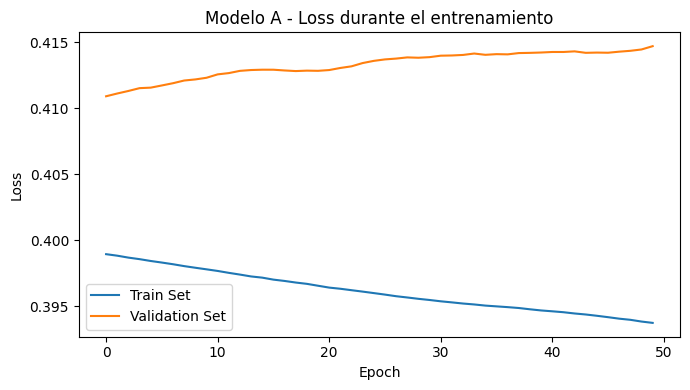

In [ ]:
# Graficamos la evolución del error (loss) durante el entrenamiento
# Comparamos el conjunto de entrenamiento con el conjunto de validación

plt.figure(figsize=(7, 4))

# Loss calculado sobre los datos usados para entrenar el modelo
plt.plot(history_a.history["loss"], label="Train Set")

# Loss calculado sobre los datos de validación (datos no usados para actualizar pesos)
plt.plot(history_a.history["val_loss"], label="Validation Set")

# Título y etiquetas del gráfico
plt.title("Modelo A - Loss durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.tight_layout()
plt.show()

**Indicio de overfitting ?**

el loss de entrenamiento sigue bajando durante todo el entrenamiento, pero el loss de validación deja de mejorar en algún punto (alrededor del epoch 20 en nuestra corrida) y después empieza a subir muy lentamente.

Esa separación entre ambas curvas, aunque acá es chica, es la firma clásica del overfitting: pasado ese punto, seguir entrenando ayuda al modelo a ajustarse mejor a los datos de entrenamiento, pero no mejora (e incluso empeora un poco) su desempeño sobre datos que no vio.

**incluso modelo muy simple puede empezar a sobreajustar** si lo entrenamos suficientes epochs.

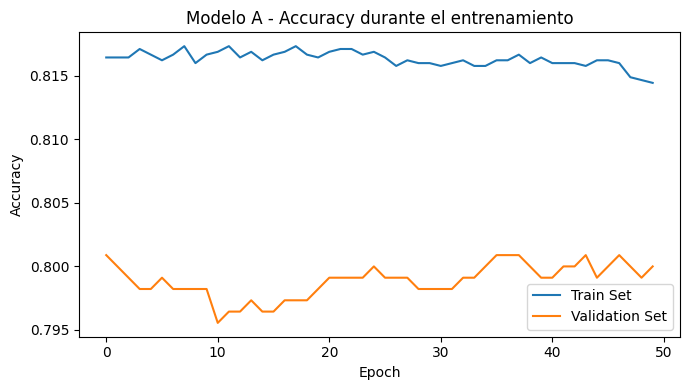

In [ ]:
# Graficamos la evolución de la accuracy durante el entrenamiento
# Comparando entrenamiento y validación

plt.figure(figsize=(7, 4))

# Accuracy sobre los datos de entrenamiento
plt.plot(history_a.history["accuracy"], label="Train Set")

# Accuracy sobre los datos de validación
plt.plot(history_a.history["val_accuracy"], label="Validation Set")

# Título y etiquetas del gráfico
plt.title("Modelo A - Accuracy durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")


plt.legend()
plt.tight_layout()
plt.show()

**Cómo interpretar las curvas de accuracy de entrenamiento y validación**

El gráfico de **accuracy de entrenamiento vs accuracy de validación** permite evaluar si la red está aprendiendo patrones útiles y si es capaz de generalizar a datos nuevos.

- Un comportamiento esperado es que ambas curvas aumenten durante las primeras épocas y permanezcan relativamente cercanas.
  Esto indica que el modelo aprende correctamente y no está memorizando los datos de entrenamiento.

- **Overfitting (sobreajuste):** ocurre cuando la accuracy de entrenamiento sigue aumentando, pero la accuracy de validación deja de mejorar o empieza a disminuir.
  El modelo aprende demasiado los ejemplos de entrenamiento y pierde capacidad de generalización.

- **Underfitting (subajuste):** ocurre cuando tanto la accuracy de entrenamiento como la de validación permanecen bajas.
  Esto indica que el modelo no tiene suficiente capacidad para aprender los patrones de los datos.

En general, buscamos un modelo con:
- Alta accuracy de validación.
- Una diferencia pequeña entre entrenamiento y validación.
- Buen rendimiento sobre el conjunto de test.

La mejor red es la que consigue el mejor equilibrio entre aprendizaje y generalización.

In [ ]:
# Evaluamos el Modelo A sobre el conjunto de test, que el modelo nunca vio
test_loss, test_accuracy = modelo_a.evaluate(X_test_scaled, y_test, verbose=0)

print("Loss en el conjunto de test:", test_loss)
print("Accuracy en el conjunto de test:", test_accuracy)


Loss en el conjunto de test: 0.4432732164859772
Accuracy en el conjunto de test: 0.7839374542236328


Resultados obtenidos:

- **Loss en test:** 0.443  
- **Accuracy en test:** 78.4%

El accuracy de test es cercano al obtenido durante el entrenamiento y validación,
lo que indica que el modelo no presenta una señal clara de sobreajuste (*overfitting*).

Sin embargo, existe una pequeña caída respecto al entrenamiento, lo cual es normal:
el modelo funciona algo mejor con datos conocidos que con datos nuevos.

En conclusión, el modelo aprende patrones útiles y generaliza razonablemente bien,
aunque todavía existe margen de mejora mediante ajuste de arquitectura,
hiperparámetros o técnicas de regularización.

## Cierre de la sesión

Hoy hicimos lo siguiente:

- Preparamos un dataset real de churn para que una red neuronal lo pueda usar:
  limpieza, encoding y scaling.
- Entendimos, implementando con numpy, qué hace matemáticamente una neurona y
  una capa (suma ponderada + activación), antes de dejar que Keras lo haga
  automáticamente.
- Construimos y entrenamos nuestro primer modelo real: el **Modelo A - El
  Minimalista**.
- Analizamos sus curvas de loss y accuracy.